0    0.935326
1    2.135887
2    2.855971
3    2.530155
4    1.983404
Name: years_experience_log1p, dtype: float64
hours_experience_bins_width
Entry Level    344
Mid-Level       89
Senior          38
Expert          31
Name: count, dtype: int64
    age   salary  years_experience  weekly_hours  performance_score   bonus  \
0  56.0   7000.0          1.548044          57.0               3.76  4104.0   
1  46.0   8052.0          7.464551          34.0               1.80  1169.0   
2  32.0  10942.0         16.391317          53.0               3.14  4864.0   
3  60.0   8387.0         11.555457          54.0               1.39  1783.0   
4  25.0  10942.0          6.267442          44.0               2.80  1423.0   

   projects_handled education_level region  employment_type_Contract  ...  \
0         10.255061             PhD  North                      True  ...   
1          7.000000          Master  North                     False  ...   
2          1.000000     High School   West       

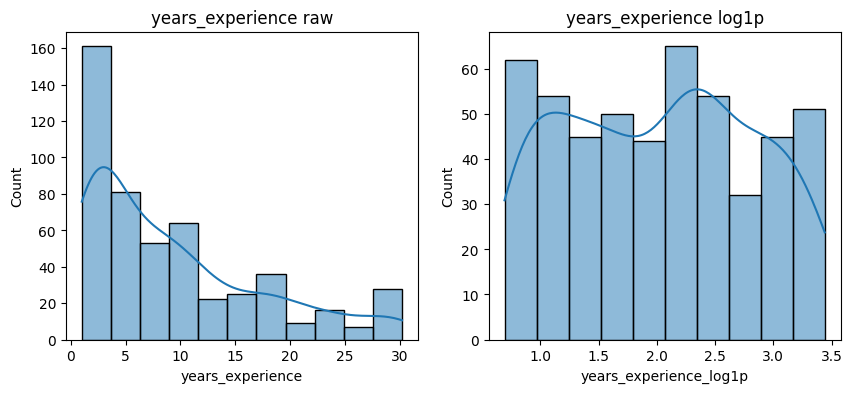

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import cleaning_01  as r
df1 = r.df.copy()


df1 = pd.get_dummies(df1, columns=["employment_type",'department'], prefix=["employment_type",'department'])#one-hot encode (employment_type , department) columns

education_order = pd.CategoricalDtype(
categories=["High School", "Bachelor", "Master",'PhD'], ordered=True)
df1["education_ord"] = df1["education_level"].astype(education_order).cat.codes# Ordinal encode education_level column

df2 = df1.copy()


std_scaler = StandardScaler()
df2[["years_experience_std", "weekly_hours_std"]] = std_scaler.fit_transform(df2[["years_experience" ,"weekly_hours"]])#scaling (years_experience_std,weekly_hours_std)columns using StandardScaler

df3= df2.copy()

df3["bonus_per_year_experience"] = df3["bonus"] / df3["years_experience"].replace({0: np.nan})
df3["bonus_per_year_experience"] = df3["bonus_per_year_experience"].fillna(df3["bonus_per_year_experience"].median())#It helps us predict salary in a specific year.
df3["projects_handled_per_year_experience"] = df3['projects_handled'] / df3["years_experience"].replace({0: np.nan})
df3["projects_handled_per_year_experience"] = df3["projects_handled_per_year_experience"].fillna(
df3["projects_handled_per_year_experience"].median())#It helps us understand performance score , and through it we can predict salary.
yearly_hours = df3['weekly_hours']* 52
df3['hours_experience'] = df3['years_experience'] * yearly_hours # Based on hours of experience, predict salary (target).
                                                                #A more accurate criterion than years of experience alone.

df4 = df3.copy()

df4["years_experience_log1p"] = np.log1p(df4["years_experience"])#  Log-transform application
# showing deference before and after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df4["years_experience"], ax=axes[0], kde= True); axes[0].set_title("years_experience raw")
sns.histplot(df4["years_experience_log1p"], ax=axes[1], kde = True); axes[1].set_title("years_experience log1p")
print(df4['years_experience_log1p'].head())


df5 = df4.copy()

bin_edges = [0, 22400 , 38700 , 58400, 120000]
labels = ["Entry Level", "Mid-Level",'Senior', "Expert"]
df5["hours_experience_bins_width"] = pd.cut(df5["hours_experience"], bins=bin_edges, labels=labels, right=False)#binning application based on hours experience
print(df5["hours_experience_bins_width"].value_counts())

df6 = df5.copy()

numeric_col = ['age' ,  'salary' , 'years_experience' , 'weekly_hours' , 'performance_score' , 'bonus' , 'projects_handled',
'years_experience_std','weekly_hours_std','bonus_per_year_experience','projects_handled_per_year_experience',
'hours_experience','years_experience_log1p']

# removing redundent features
def drop_correlated_features(df, threshold=0.95):
  corr_matrix = df[numeric_col].corr().abs()#finding correlated between columns
  upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
  to_drop = [col for col in upper.columns if any(upper[col] > threshold)]# writing columns that is redundent
  return df.drop(columns=to_drop), to_drop

df6, x =drop_correlated_features(df6, threshold=0.95)
df7 = df6.copy()

print(df7.head())
